# Ứng dụng xử lý ngôn ngữ tự nhiên trong phân tích cảm xúc và chủ đề từ review game Darkest Dungeon trên Steam

### Bước 1: Thiết lập môi trường và import thư viện

In [3]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer
from gensim import corpora
from gensim.models import LdaModel

PROJECT_ROOT = Path.cwd().resolve().parents[0] if (Path.cwd() / 'src').exists() else Path.cwd()
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'darkest_dungeon_reviews.csv'
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'darkest_dungeon_reviews_clean.csv'
THEMES_PATH = PROJECT_ROOT / 'config' / 'themes.json'

pd.set_option('display.max_colwidth', 120)

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

nltk.download('movie_reviews', quiet=True)


True

### Bước 2: Thu thập dữ liệu

In [4]:
if RAW_PATH.exists():
    df = pd.read_csv(RAW_PATH)
    print(df.shape)
    display(df.head())
else:
    print(f'Missing file: {RAW_PATH}')
    print('Run: python fetch_reviews.py')


(64192, 50)


C:\Users\LEGION\AppData\Local\Temp\ipykernel_23148\1901801561.py:2: DtypeWarning: Columns (7,12,13,14,15,16,30,31,32,37,38,39,41,43,44,45,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH)


,query_summary,cursors,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,...,hardware.gaming_device_type,hardware.dx_driver_version,hardware.dx_driver_name,hardware.adapter_description,hardware.driver_version,hardware.driver_date,hardware.vram_size,author.deck_playtime_at_review,timestamp_dev_responded,developer_response
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,221483584.0,english,DECISIVE!!!,1.774270e+09,1.774270e+09,True,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,221483262.0,english,Me in 2016: wth is this theater doll ah game garbage\n\n\nMe in 2026: STUNT BLIGHT BLEED GO BRRRRRRR,1.774270e+09,1.774270e+09,True,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,221471689.0,english,"Que juego de mierda, recomendado.",1.774257e+09,1.774257e+09,True,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,221462393.0,english,"Definitely an interesting and fun idea but I can't stand what this game does to me.\nI started a new game, finished ...",1.774245e+09,1.774245e+09,False,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Bước 3: Làm sạch dữ liệu và tiền xử lý

In [ ]:
import re
import html
import unicodedata
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words('english'))
# Giữ lại một số từ phủ định quan trọng để không làm mất nghĩa sentiment
negation_keep = {"no", "not", "nor", "never"}
# Stopwords tùy chỉnh để giảm từ quá chung chung trong review game
custom_remove = {
    "game", "play", "player", "steam",
    "one", "get", "got", "make", "made", "really",
    "thing", "things", "would", "could", "also"
}
final_stopwords = (stop_words - negation_keep) | custom_remove
lemmatizer = WordNetLemmatizer()
# Mở rộng contraction trước khi tokenize
contractions_map = {
    "can't": "can not",
    "cannot": "can not",
    "won't": "will not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "shouldn't": "should not",
    "wouldn't": "would not",
    "couldn't": "could not",
    "mustn't": "must not",
    "mightn't": "might not",
    "needn't": "need not",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would",
    "you're": "you are",
    "you've": "you have",
    "you'll": "you will",
    "you'd": "you would",
    "we're": "we are",
    "we've": "we have",
    "we'll": "we will",
    "we'd": "we would",
    "they're": "they are",
    "they've": "they have",
    "they'll": "they will",
    "they'd": "they would",
    "he's": "he is",
    "she's": "she is",
    "let's": "let us",
    "n't": " not",
    "'re": " are",
    "'ve": " have",
    "'ll": " will",
    "'d": " would",
    "'m": " am"
}

def expand_contractions(text: str) -> str:
    text = str(text)
    for k, v in contractions_map.items():
        text = re.sub(rf"\b{re.escape(k)}\b", v, text, flags=re.IGNORECASE)
    return text

def normalize_text(text: str) -> str:
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"http\S+|www\.\S+", " ", text)   
    text = re.sub(r"<.*?>", " ", text)              
    text = expand_contractions(text.lower())
    return text

def clean_text(text):
    text = normalize_text(text)

    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = word_tokenize(text)

    cleaned_words = []
    for w in words:
        w = re.sub(r"[^a-z]", "", w)
        if not w:
            continue
        if len(w) <= 1:   
            continue
        if w in final_stopwords:
            continue
        lemma = lemmatizer.lemmatize(w)
        if lemma and lemma not in final_stopwords:
            cleaned_words.append(lemma)

    return " ".join(cleaned_words)

if RAW_PATH.exists():
    clean_df = df.dropna(subset=['review']).copy()

    if 'language' in clean_df.columns:
        clean_df = clean_df[
            clean_df['language'].astype(str).str.lower() == 'english'
        ].copy()

    clean_df = clean_df[
        clean_df['review'].apply(
            lambda x: len(re.findall(r'\b\w+\b', str(x))) > 5
            and bool(re.search(r'[a-zA-Z]', str(x)))
        )
    ].copy()

    clean_df['review_length'] = clean_df['review'].astype(str).str.split().str.len()

    if 'author.playtime_forever' in clean_df.columns:
        clean_df['playtime_hours'] = clean_df['author.playtime_forever'].fillna(0) / 60.0
        clean_df['playtime_bucket'] = pd.qcut(
            clean_df['playtime_hours'].rank(method='first'),
            4,
            labels=['low', 'medium', 'high', 'very_high']
        )

    clean_df['review_clean'] = clean_df['review'].apply(clean_text)

    clean_df = clean_df[
        clean_df['review_clean'].apply(lambda x: len(str(x).split()) >= 3)
    ].copy()

    PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
    clean_df.to_csv(PROCESSED_PATH, index=False)

    print(clean_df.shape)
    display(clean_df[['review', 'review_clean']].head())


(46597, 54)


,review,review_clean
2,Me in 2016: wth is this theater doll ah game garbage\n\n\nMe in 2026: STUNT BLIGHT BLEED GO BRRRRRRR,wth theater doll ah garbage stunt blight bleed go brrrrrrr
4,"Definitely an interesting and fun idea but I can't stand what this game does to me.\nI started a new game, finished ...",definitely interesting fun idea not stand started new finished tutorial without incident completed first mission wel...
6,"Needlessly hard and oppressive. Played for 115 horus, and wish I had that time back.",needlessly hard oppressive played horus wish time back
7,"Fun, challenging, and visually appealing take on turn-based dungeon crawlers :)",fun challenging visually appealing take turn based dungeon crawler
12,"Good idea but overall very boring gameplay loop, boring ass repetitive charecters that fall into the same 4 templat...",good idea overall boring gameplay loop boring repetitive charecters fall template walking section kinda goofy lotta ...


### Bước 4: Phân tích khám phá dữ liệu (EDA)

In [10]:
if PROCESSED_PATH.exists():
    eda_df = pd.read_csv(PROCESSED_PATH)
    if 'voted_up' in eda_df.columns:
        print(eda_df['voted_up'].value_counts(dropna=False))
    print(eda_df['review_length'].describe())
    if 'playtime_hours' in eda_df.columns:
        print(eda_df['playtime_hours'].describe())


voted_up
True     41429
False     5168
Name: count, dtype: int64
count    46597.000000
mean        75.845162
std        133.416203
min          2.000000
25%         13.000000
50%         30.000000
75%         78.000000
max       1492.000000
Name: review_length, dtype: float64
count    46597.000000
mean       148.050738
std        252.806913
min          0.016667
25%         32.400000
50%         81.050000
75%        172.316667
max       9609.083333
Name: playtime_hours, dtype: float64


C:\Users\LEGION\AppData\Local\Temp\ipykernel_23148\683327348.py:2: DtypeWarning: Columns (30,31,32,37,38,39,41,43,44,45,49) have mixed types. Specify dtype option on import or set low_memory=False.
  eda_df = pd.read_csv(PROCESSED_PATH)


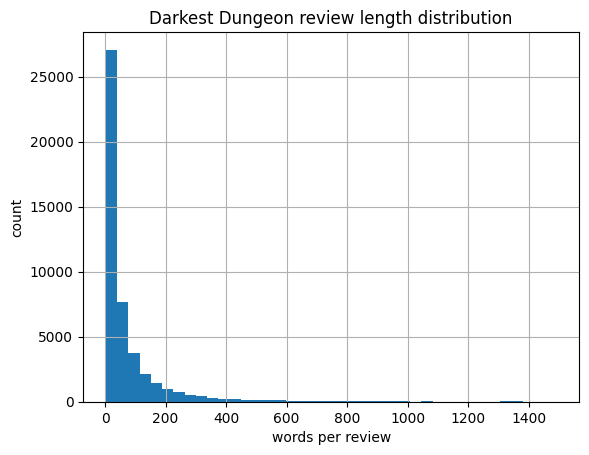

In [11]:
if PROCESSED_PATH.exists():
    eda_df['review_length'].hist(bins=40)
    plt.title('Darkest Dungeon review length distribution')
    plt.xlabel('words per review')
    plt.ylabel('count')
    plt.show()


### Bước 5: Mô hình có giám sát cơ sở

Trước hết, kiểm tra xem **nội dung review có dự đoán được nhóm thời lượng chơi (`playtime_bucket`) hay không**.

**Vì sao dùng Logistic Regression cho bài toán này?**
- Đây là mô hình cơ sở đơn giản, dễ diễn giải và chạy nhanh trên dữ liệu văn bản sau khi biến đổi bằng TF-IDF.
- Logistic Regression thường là lựa chọn mạnh và ổn định cho các bài toán phân loại văn bản baseline.
- Kết quả của mô hình này giúp đánh giá liệu phần văn bản review có chứa tín hiệu liên quan đến mức độ gắn bó của người chơi hay không.
- Vì mục tiêu là xây baseline trước khi thử các hướng khác, một mô hình tuyến tính như Logistic Regression là phù hợp hơn so với việc dùng mô hình quá phức tạp ngay từ đầu.

In [12]:
if PROCESSED_PATH.exists() and 'playtime_bucket' in eda_df.columns:
    model_df = eda_df.dropna(subset=['review_clean','playtime_bucket']).copy()
    X_train, X_test, y_train, y_test = train_test_split(
        model_df['review_clean'], model_df['playtime_bucket'],
        test_size=0.2, random_state=42, stratify=model_df['playtime_bucket']
    )
    clf = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('logreg', LogisticRegression(max_iter=2000))
    ])
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    print(classification_report(y_test, preds))


              precision    recall  f1-score   support

        high       0.26      0.24      0.25      2334
         low       0.36      0.44      0.40      2334
      medium       0.28      0.24      0.26      2328
   very_high       0.35      0.36      0.36      2324

    accuracy                           0.32      9320
   macro avg       0.31      0.32      0.32      9320
weighted avg       0.31      0.32      0.32      9320



### Bước 5B: Logistic Regression cho bài toán dự đoán mức độ tích cực của review

Ở đây, ta huấn luyện **Logistic Regression** để dự đoán một review Steam có được khuyến nghị hay không (`voted_up`) chỉ từ nội dung văn bản.

**Vì sao dùng Logistic Regression cho bài toán này?**
- `voted_up` là nhãn nhị phân, rất phù hợp với bản chất của Logistic Regression.
- Với dữ liệu văn bản đã được mã hóa bằng TF-IDF, Logistic Regression là một baseline rất phổ biến, dễ huấn luyện và dễ so sánh.
- Hệ số của mô hình tuyến tính cũng giúp diễn giải theo hướng những từ/cụm từ nào đang góp phần phân biệt review tích cực và tiêu cực.
- Mục tiêu của bước này không phải tìm mô hình tốt nhất cuối cùng, mà là thiết lập một mốc baseline và kiểm tra xem tình trạng lệch lớp mạnh có làm cho bài toán này kém thông tin hay không.

In [14]:

review_col = 'review_clean' if 'review_clean' in eda_df.columns else (
    'cleaned_review' if 'cleaned_review' in eda_df.columns else (
        'review' if 'review' in eda_df.columns else 'review_text'
    )
)

if PROCESSED_PATH.exists() and review_col in eda_df.columns and 'voted_up' in eda_df.columns:
    sentiment_df = eda_df.dropna(subset=[review_col, 'voted_up']).copy()
    sentiment_df[review_col] = sentiment_df[review_col].astype(str)

    if sentiment_df['voted_up'].dtype == bool:
        sentiment_df['voted_up_binary'] = sentiment_df['voted_up'].astype(int)
    else:
        sentiment_df['voted_up_binary'] = (
            sentiment_df['voted_up']
            .astype(str)
            .str.lower()
            .map({'true': 1, 'false': 0, '1': 1, '0': 0})
        )

    sentiment_df = sentiment_df.dropna(subset=['voted_up_binary']).copy()
    sentiment_df['voted_up_binary'] = sentiment_df['voted_up_binary'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        sentiment_df[review_col],
        sentiment_df['voted_up_binary'],
        test_size=0.2,
        random_state=42,
        stratify=sentiment_df['voted_up_binary']
    )

    logreg_sentiment = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('logreg', LogisticRegression(max_iter=2000))
    ])

    logreg_sentiment.fit(X_train, y_train)
    sentiment_preds = logreg_sentiment.predict(X_test)

    print('Label distribution (0 = not recommended, 1 = recommended):')
    print(sentiment_df['voted_up_binary'].value_counts(normalize=True).sort_index())
    print('\nClassification report for Logistic Regression on voted_up:')
    print(classification_report(y_test, sentiment_preds))
else:
    print('Required columns for Logistic Regression were not found.')

Label distribution (0 = not recommended, 1 = recommended):
voted_up_binary
0    0.110908
1    0.889092
Name: proportion, dtype: float64

Classification report for Logistic Regression on voted_up:
              precision    recall  f1-score   support

           0       0.82      0.47      0.60      1034
           1       0.94      0.99      0.96      8286

    accuracy                           0.93      9320
   macro avg       0.88      0.73      0.78      9320
weighted avg       0.92      0.93      0.92      9320



### Bước 5C: XGBoost cho bài toán dự đoán người chơi có thời lượng chơi trên trung bình hay không


**Vì sao dùng XGBoost cho bài toán này?**
- Đây là mô hình boosting mạnh, thường cho kết quả tốt khi cần học các ranh giới phân loại phức tạp hơn baseline tuyến tính.
- Bài toán above/below-average playtime mang tính hành vi hơn, và quan hệ giữa ngôn ngữ trong review với mức độ chơi có thể không hoàn toàn tuyến tính.
- XGBoost có khả năng khai thác tín hiệu phi tuyến và tương tác đặc trưng tốt hơn so với Logistic Regression.
- Sau khi đã có baseline đơn giản, việc dùng XGBoost giúp kiểm tra xem mô hình mạnh hơn có tận dụng được thêm tín hiệu từ dữ liệu hay không.

Để thời gian chạy hợp lý, phần này có thể chỉ sử dụng một tập con dữ liệu khi kích thước tập review quá lớn.

In [15]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False
    print('xgboost is not installed. Run `pip install xgboost` to enable this section.')

playtime_col = 'playtime_hours' if 'playtime_hours' in eda_df.columns else (
    'author.playtime_forever' if 'author.playtime_forever' in eda_df.columns else (
        'author_playtime_forever' if 'author_playtime_forever' in eda_df.columns else None
    )
)

if xgb_available and PROCESSED_PATH.exists() and review_col in eda_df.columns and playtime_col is not None:
    xgb_df = eda_df.dropna(subset=[review_col, playtime_col]).copy()
    xgb_df[review_col] = xgb_df[review_col].astype(str)

    if playtime_col in ['author.playtime_forever', 'author_playtime_forever']:
        xgb_df['playtime_hours_model'] = pd.to_numeric(xgb_df[playtime_col], errors='coerce') / 60.0
    else:
        xgb_df['playtime_hours_model'] = pd.to_numeric(xgb_df[playtime_col], errors='coerce')

    xgb_df = xgb_df.dropna(subset=['playtime_hours_model']).copy()

    mean_playtime = xgb_df['playtime_hours_model'].mean()
    xgb_df['above_avg_playtime'] = (xgb_df['playtime_hours_model'] >= mean_playtime).astype(int)

    subset_n = min(len(xgb_df), 15000)
    xgb_sample = xgb_df.sample(n=subset_n, random_state=42) if len(xgb_df) > subset_n else xgb_df.copy()

    X = xgb_sample[review_col]
    y = xgb_sample['above_avg_playtime']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    tfidf_for_xgb = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_tfidf = tfidf_for_xgb.fit_transform(X_train)
    X_test_tfidf = tfidf_for_xgb.transform(X_test)

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )

    xgb_model.fit(X_train_tfidf, y_train)
    xgb_preds = xgb_model.predict(X_test_tfidf)

    print(f'Mean playtime threshold (hours): {mean_playtime:.2f}')
    print('Label distribution (0 = below average, 1 = above average):')
    print(xgb_sample['above_avg_playtime'].value_counts(normalize=True).sort_index())
    print('\nClassification report for XGBoost on above/below-average playtime:')
    print(classification_report(y_test, xgb_preds))
else:
    if playtime_col is None:
        print('No compatible playtime column was found for the XGBoost section.')

Mean playtime threshold (hours): 148.05
Label distribution (0 = below average, 1 = above average):
above_avg_playtime
0    0.709067
1    0.290933
Name: proportion, dtype: float64

Classification report for XGBoost on above/below-average playtime:
              precision    recall  f1-score   support

           0       0.72      0.96      0.82      2127
           1       0.47      0.08      0.14       873

    accuracy                           0.71      3000
   macro avg       0.59      0.52      0.48      3000
weighted avg       0.65      0.71      0.62      3000



### Bước 6: Phân tích cảm xúc bằng TextBlob với NaiveBayesAnalyzer

Ta sử dụng **NaiveBayesAnalyzer (NBA)** của TextBlob để phân tích cảm xúc ở hai mức:

- **Mức toàn review**: một điểm cho toàn bộ review
- **Mức câu/chủ đề**: một điểm cho từng câu có nhắc đến một chủ đề của Darkest Dungeon

Với Darkest Dungeon, bốn chủ đề được lưu trong `themes.json` và tập trung vào:
- `combat`
- `stress_psychology`
- `art_atmosphere`
- `progression_difficulty`

Đối với điểm cảm xúc tổng quát, notebook chuyển xác suất Naive Bayes thành một thang điểm liên tục:

`general_sentiment_score = p_pos - p_neg`

Thang điểm này nằm trong khoảng **[-1, 1]**, trong đó:
- giá trị gần **1** là rất tích cực
- giá trị gần **-1** là rất tiêu cực
- giá trị gần **0** là trung tính hoặc pha trộn

In [16]:
with open(THEMES_PATH, 'r', encoding='utf-8') as f:
    themes = json.load(f)

nba = NaiveBayesAnalyzer()

def sentence_mentions_theme(sentence, keywords):
    sentence = sentence.lower()
    return any(re.search(r'\b' + re.escape(k.lower()) + r'\b', sentence) for k in keywords)

def nba_score(text):
    text = str(text).strip()
    if not text:
        return {'classification': 'neu', 'p_pos': 0.5, 'p_neg': 0.5, 'score': 0.0}
    try:
        sentiment = TextBlob(text, analyzer=nba).sentiment
        p_pos = float(sentiment.p_pos)
        p_neg = float(sentiment.p_neg)
        return {
            'classification': sentiment.classification,
            'p_pos': p_pos,
            'p_neg': p_neg,
            'score': p_pos - p_neg
        }
    except Exception:
        return {'classification': 'neu', 'p_pos': 0.5, 'p_neg': 0.5, 'score': 0.0}

def score_review(review):
    review = str(review)
    overall = nba_score(review)
    out = {
        'overall_classification': overall['classification'],
        'overall_p_pos': overall['p_pos'],
        'overall_p_neg': overall['p_neg'],
        'general_sentiment_score': overall['score']
    }

    try:
        sentences = [str(s) for s in TextBlob(review).sentences] or [review]
    except Exception:
        sentences = [review]

    for theme, keywords in themes.items():
        theme_scores = []
        count = 0
        for sent in sentences:
            if sentence_mentions_theme(sent, keywords):
                count += 1
                theme_scores.append(nba_score(sent)['score'])
        out[f'{theme}_mentions'] = count
        out[f'{theme}_sentiment_score'] = float(np.mean(theme_scores)) if theme_scores else 0.0
    return pd.Series(out)

if PROCESSED_PATH.exists():
    theme_scores = eda_df['review'].fillna('').astype(str).apply(score_review)
    themed_df = pd.concat([eda_df, theme_scores], axis=1)
    display(themed_df.head())


,query_summary,cursors,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,...,overall_p_neg,general_sentiment_score,combat_mentions,combat_sentiment_score,stress_psychology_mentions,stress_psychology_sentiment_score,art_atmosphere_mentions,art_atmosphere_sentiment_score,progression_difficulty_mentions,progression_difficulty_sentiment_score
0,NaN,NaN,221483262.0,english,Me in 2016: wth is this theater doll ah game garbage\n\n\nMe in 2026: STUNT BLIGHT BLEED GO BRRRRRRR,1.774270e+09,1.774270e+09,True,0.0,0.0,...,0.957258,-0.914516,0,0.000000,0,0.0,0,0.0,0,0.000000
1,NaN,NaN,221462393.0,english,"Definitely an interesting and fun idea but I can't stand what this game does to me.\nI started a new game, finished ...",1.774245e+09,1.774245e+09,False,0.0,0.0,...,0.000263,0.999474,4,0.076129,0,0.0,0,0.0,2,0.087476
2,NaN,NaN,221449081.0,english,"Needlessly hard and oppressive. Played for 115 horus, and wish I had that time back.",1.774230e+09,1.774230e+09,False,0.0,0.0,...,0.856935,-0.713870,0,0.000000,0,0.0,0,0.0,1,0.191575
3,NaN,NaN,221430507.0,english,"Fun, challenging, and visually appealing take on turn-based dungeon crawlers :)",1.774214e+09,1.774214e+09,True,0.0,0.0,...,0.115780,0.768440,1,0.768440,0,0.0,0,0.0,1,0.768440
4,NaN,NaN,221374929.0,english,"Good idea but overall very boring gameplay loop, boring ass repetitive charecters that fall into the same 4 templat...",1.774178e+09,1.774178e+09,False,0.0,0.0,...,0.978409,-0.956817,0,0.000000,0,0.0,0,0.0,1,-0.956817


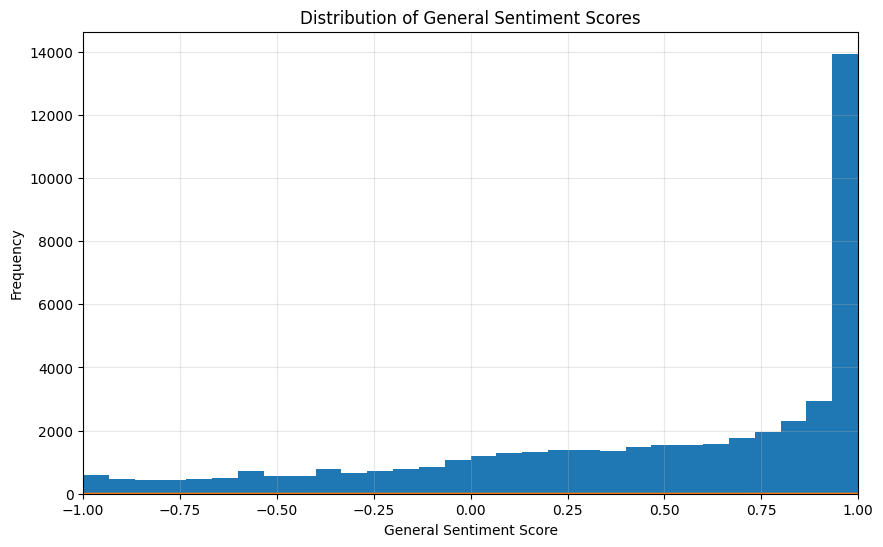

In [17]:
if PROCESSED_PATH.exists():
    plt.figure(figsize=(10, 6))
    themed_df['general_sentiment_score'].dropna().hist(bins=30)
    themed_df['general_sentiment_score'].dropna().plot(kind='kde')
    plt.title('Distribution of General Sentiment Scores')
    plt.xlabel('General Sentiment Score')
    plt.ylabel('Frequency')
    plt.xlim(-1, 1)
    plt.grid(alpha=0.3)
    plt.show()


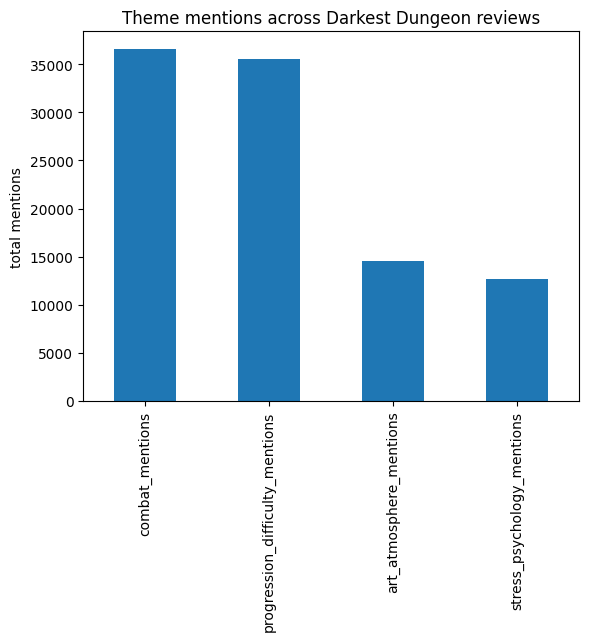

,count
combat_mentions,36574
progression_difficulty_mentions,35524
art_atmosphere_mentions,14520
stress_psychology_mentions,12708


In [18]:
if PROCESSED_PATH.exists():
    mention_cols = [c for c in themed_df.columns if c.endswith('_mentions')]
    mention_totals = themed_df[mention_cols].sum().sort_values(ascending=False)
    mention_totals.plot(kind='bar')
    plt.title('Theme mentions across Darkest Dungeon reviews')
    plt.ylabel('total mentions')
    plt.show()
    display(mention_totals.to_frame('count'))


### Bước 7: Mô hình chủ đề với LDA

In [19]:
if PROCESSED_PATH.exists():
    eda_df = pd.read_csv(PROCESSED_PATH, low_memory=False)

    tokens = [txt.split() for txt in eda_df['review_clean'].dropna().astype(str)]
    dictionary = corpora.Dictionary(tokens)
    dictionary.filter_extremes(no_below=10, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in tokens]

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=6,
        random_state=42,
        passes=10
    )

    for idx in range(6):
        words_with_weights = lda.show_topic(idx, topn=10)
        keywords = [word for word, weight in words_with_weights]
        print(f"Topic {idx}: {', '.join(keywords)}")

Topic 0: not, love, back, like, time, die, good, go, hard, keep
Topic 1: like, based, turn, dark, rpg, dungeon, best, not, soul, rogue
Topic 2: dungeon, darkest, hero, party, character, well, feel, every, not, come
Topic 3: stress, character, hero, party, not, level, dungeon, enemy, attack, hit
Topic 4: not, time, like, early, hour, rng, even, access, fun, good
Topic 5: great, art, style, gameplay, good, fun, atmosphere, amazing, voice, love


### Bước 8: Các bigram nổi bật

In [20]:
if PROCESSED_PATH.exists():
    vectorizer = CountVectorizer(ngram_range=(2,2), max_features=40)
    X = vectorizer.fit_transform(eda_df['review_clean'].fillna(''))
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    bigrams = pd.DataFrame({'bigram': vocab, 'count': counts}).sort_values('count', ascending=False)
    display(bigrams.head(20))


,bigram,count
7,darkest dungeon,8395
38,turn based,4337
0,art style,2153
16,feel like,1979
9,dungeon crawler,1782
12,early access,1744
6,dark soul,1477
18,heart attack,1346
34,party member,1095
1,based combat,1046


### Bước 9: Lấy mẫu ngẫu nhiên review kèm polarity theo chủ đề

In [21]:
sample_cols = ['review', 'review_length']

for col in ['overall_classification', 'overall_p_pos', 'overall_p_neg', 'general_sentiment_score']:
    if col in themed_df.columns:
        sample_cols.append(col)

sample_cols += [c for c in themed_df.columns if c.endswith('_polarity')]

sample = themed_df[sample_cols].sample(1, random_state=42)
display(sample.T)

,13082
review,Time and time again I return to this game and it keeps reminding me of ——that overconfidence is a slow and insidious...
review_length,23
overall_classification,pos
overall_p_pos,0.575843
overall_p_neg,0.424157
general_sentiment_score,0.151685
